# Clasificación de Deserción Estudiantil con SVM: Flujo Reproducible Sin Fuga de Datos

**Proyecto**: Machine Learning II - Universidad 2026-II  
**Autor**: Arnold Santiago Torres  
**Dataset**: `estudiantes_sinteticos_11500.csv` (11,500 registros, 21 variables socioeconómicas y académicas)  

---  
### Sección 7.2: Flujo Reproducible Sin Fuga de Datos (Data Leakage Prevention)

Se integra el preprocesamiento (`ColumnTransformer`: codificación de categóricas + escalamiento numérico) y el estimador (`SVC`) en un **Pipeline** reproducible de Scikit-Learn.  
Esto garantiza que **todas las transformaciones se ajusten (`fit`) ÚNICAMENTE con los datos de entrenamiento de cada partición (`X_train`)**, evitando estrictamente la contaminación o fuga de información hacia el conjunto de prueba (`X_test`).
---

In [10]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from joblib import Parallel, delayed, dump

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, MaxAbsScaler,
    QuantileTransformer, PowerTransformer, OrdinalEncoder, OneHotEncoder, FunctionTransformer
)
from scipy.stats import ttest_ind

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['font.sans-serif'] = 'Arial'

N_JOBS = 2  # Usar 2 núcleos del procesador
print(f"Configuración de ejecuciones con Pipelines usando {N_JOBS} núcleos de la CPU.")

Configuración de ejecuciones con Pipelines usando 2 núcleos de la CPU.


## 1. Carga de Datos, Descripción de Variables y Análisis Estadístico Descriptivo

### 1.1 Descripción de las Variables del Dataset (`estudiantes_sinteticos_11500.csv`)
El conjunto de datos contiene 11,500 registros de estudiantes con 21 variables predictoras (11 numéricas y 10 categóricas) y 1 variable objetivo binaria (`desercion`).

| Variable | Tipo de Dato | Dimensión | Rango Original / Valores | Descripción Detallada |
| :--- | :--- | :--- | :--- | :--- |
| **`edad_ingreso`** | Numérica (Entero) | Socio-Demográfica | `[15 - 32]` años | Edad del estudiante al momento de ingresar a la educación superior. |
| **`sexo`** | Categórica | Socio-Demográfica | `'Hombre'`, `'Mujer'` | Género con el que se identifica el estudiante. |
| **`estado_civil`** | Categórica | Socio-Demográfica | `'Soltero'`, `'Union libre'`, `'Casado'`, `'Otro'` | Estado civil reportado en la matrícula. |
| **`zona_residencia`** | Categórica | Geográfica | `'Urbana'`, `'Rural'` | Zona geográfica del hogar de origen. |
| **`departamento`** | Categórica | Geográfica | 27 Departamentos de Colombia | Departamento de procedencia del estudiante. |
| **`distancia_hogar_ies_km`** | Numérica (Continuo) | Geográfica | `[0.22 - 250.00]` km | Distancia estimada entre la vivienda y la sede de la IES. |
| **`promedio_academico`** | Numérica (Continuo) | Académica | `[0.87 - 5.00]` | Promedio acumulado de notas en la escala colombiana (0.0 a 5.0). |
| **`materias_reprobadas`** | Numérica (Entero) | Académica | `[0 - 12]` asignaturas | Total acumulado de asignaturas perdidas/reprobadas. |
| **`puntaje_icfes_percentil`** | Numérica (Entero) | Académica | `[1 - 100]` percentil | Posición relativa (percentil) obtenida en las pruebas estatales Saber 11 / ICFES. |
| **`semestre_cursado`** | Numérica (Entero) | Académica | `[1 - 12]` semestres | Semestre académico en el que se encuentra matriculado. |
| **`nivel_formacion`** | Categórica | Académica | `'Universitario'`, `'Tecnologico'`, `'Tecnico profesional'` | Nivel del programa académico matriculado. |
| **`metodologia`** | Categórica | Académica | `'Presencial'`, `'Virtual'`, `'Distancia tradicional'` | Modalidad en la que se imparte el programa. |
| **`area_conocimiento`** | Categórica | Académica | 8 áreas del conocimiento | Campo disciplinar del programa educativo. |
| **`estrato_socioeconomico`** | Numérica (Entero) | Socioeconómica | `[1 - 6]` | Estrato socioeconómico residencial del estudiante. |
| **`nivel_educativo_padre`** | Categórica | Familiar | 6 niveles (Ninguno a Posgrado) | Máximo nivel de escolaridad alcanzado por el padre. |
| **`nivel_educativo_madre`** | Categórica | Familiar | 6 niveles (Ninguno a Posgrado) | Máximo nivel de escolaridad alcanzado por la madre. |
| **`sector_ies`** | Categórica | Institucional | `'Publico'`, `'Privado'` | Carácter del sector de la Institución de Educación Superior. |
| **`trabaja_mientras_estudia`** | Numérica (Binario) | Socioeconómica | `0` (No), `1` (Sí) | Indicador de si el estudiante labora de forma simultánea. |
| **`beneficiario_icetex`** | Numérica (Binario) | Financiera | `0` (No), `1` (Sí) | Indicador de apoyo mediante crédito o subsidio ICETEX. |
| **`beneficiario_beca`** | Numérica (Binario) | Financiera | `0` (No), `1` (Sí) | Indicador de asignación de beca académica o institucional. |
| **`anio_registro`** | Numérica (Entero) | Institucional | `[2021 - 2025]` | Año de cohorte o registro en el sistema institucional. |
| **`desercion`** (Target) | Numérica (Binario) | Objetivo | `0` (Permanece), `1` (Deserta) | Variable respuesta binaria sobre la condición final de deserción. |

### 1.2 Criterio de Construcción de la Variable Objetivo Binaria (`desercion`)

Dado que el archivo original carecía de una etiqueta explícita de deserción, la variable objetivo `desercion` fue sintetizada aplicando una **regla determinista de puntaje de riesgo ponderado ($R_i \in [0, 7.5]$)** basada en 6 condiciones críticas de vulnerabilidad:

$$
R_i = 2.5 \cdot \mathbb{I}(\text{promedio} < 3.0) + 2.5 \cdot \mathbb{I}(\text{materias\_reprobadas} \ge 2) + 1.0 \cdot \mathbb{I}(\text{icfes\_percentil} < 40) + 1.0 \cdot \mathbb{I}(\text{trabaja} = 1) + 0.5 \cdot \mathbb{I}(\text{beca} = 0) + 0.5 \cdot \mathbb{I}(\text{estrato} \le 2)
$$

#### Ponderación de Factores:
1. **Rendimiento Académico Crítico (Peso Máximo: 5.0 puntos)**:
   - `promedio_academico < 3.0` (+2.5 pts): Calificación promedio por debajo del mínimo de aprobación.
   - `materias_reprobadas >= 2` (+2.5 pts): Acumulación recurrente de asignaturas perdidas.
2. **Factores de Riesgo Medio (Peso Máximo: 2.0 puntos)**:
   - `puntaje_icfes_percentil < 40` (+1.0 pt): Competencias de ingreso en el 40% inferior nacional.
   - `trabaja_mientras_estudia == 1` (+1.0 pt): Alta presión de tiempo por doble rol académico-laboral.
3. **Vulnerabilidad Financiera y Socioeconómica (Peso Máximo: 1.0 punto)**:
   - `beneficiario_beca == 0` (+0.5 pts): Sin beca o auxilio institucional.
   - `estrato_socioeconomico <= 2` (+0.5 pts): Residencia en estratos de menores ingresos.

#### Umbral Binario de Clasificación:
$$\text{desercion}_i = \begin{cases} 1 & \text{si } R_i \ge 3.5 \quad (\text{Deserción, 33.59\%}) \\ 0 & \text{si } R_i < 3.5 \quad (\text{Permanencia, 66.41\%}) \end{cases}$$

In [11]:
data_path = 'estudiantes_sinteticos_11500.csv'
df = pd.read_csv(data_path)

# Generación del Target Binario según regla sintética de riesgo
riesgo = (
    (df['promedio_academico'] < 3.0).astype(int) * 2.5 +
    (df['materias_reprobadas'] >= 2).astype(int) * 2.5 +
    (df['puntaje_icfes_percentil'] < 40).astype(int) * 1.0 +
    (df['trabaja_mientras_estudia'] == 1).astype(int) * 1.0 +
    (df['beneficiario_beca'] == 0).astype(int) * 0.5 +
    (df['estrato_socioeconomico'] <= 2).astype(int) * 0.5
)
df['desercion'] = (riesgo >= 3.5).astype(int)

cat_cols = ['sexo', 'estado_civil', 'zona_residencia', 'departamento',
            'nivel_educativo_padre', 'nivel_educativo_madre', 'sector_ies',
            'nivel_formacion', 'metodologia', 'area_conocimiento']
num_cols = ['edad_ingreso', 'promedio_academico', 'materias_reprobadas',
            'distancia_hogar_ies_km', 'puntaje_icfes_percentil', 'semestre_cursado',
            'estrato_socioeconomico', 'anio_registro', 'trabaja_mientras_estudia',
            'beneficiario_icetex', 'beneficiario_beca']

X_raw = df[num_cols + cat_cols]
y = df['desercion'].values

print(f"Dimensiones: {df.shape[0]} estudiantes y {df.shape[1]} variables.")
print(f"Valores nulos totales: {df.isnull().sum().sum()}")
print("\nDistribución del Target Binario (1 = Deserción, 0 = No Deserción):")
print(pd.Series(y).value_counts(normalize=True) * 100)

# 1.3 Estadísticas Descriptivas y Rangos Originales (Variables Numéricas)
stats_num = df[num_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_num['Rango Original'] = stats_num.apply(lambda r: f"[{r['min']:.2f} - {r['max']:.2f}]", axis=1)
stats_num = stats_num[['mean', 'std', 'min', 'max', 'Rango Original', '25%', '50%', '75%']]
stats_num.columns = ['Media', 'Desv. Est.', 'Mínimo', 'Máximo', 'Rango Original', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)']

print("\n=== ESTADÍSTICAS DESCRIPTIVAS Y RANGOS ORIGINALES (PRE-NORMALIZACIÓN) ===")
display(stats_num)

In [12]:
# 1.4 Resumen de Variables Categóricas (Categorías Únicas Pre-encoding)
cat_summary = []
for col in cat_cols:
    uniques = df[col].unique()
    cat_summary.append({
        'Variable Categórica': col,
        'N° Categorías': len(uniques),
        'Ejemplos de Valores / Categorías': ", ".join([str(x) for x in uniques[:5]]) + ("..." if len(uniques) > 5 else "")
    })
df_cat_summary = pd.DataFrame(cat_summary)

print("=== RESUMEN DE VARIABLES CATEGÓRICAS (PRE-ENCODING) ===")
display(df_cat_summary)

### 1.5 Diagnóstico sobre Rangos Originales y Necesidad de Normalización para SVM

El análisis estadístico revela una **fuerte disparidad en las escalas originales** de los datos:

1. **Disparidad Extrema de Amplitud**:
   - `distancia_hogar_ies_km` tiene la mayor amplitud, variando entre **0.22 km y 250.00 km** ($\Delta = 249.78$).
   - `puntaje_icfes_percentil` oscila entre **1 y 100** ($\Delta = 99.00$).
   - `edad_ingreso` varía entre **15 y 32 años** ($\Delta = 17.00$).
   - `promedio_academico` opera en una escala estrecha de **0.87 a 5.00** ($\Delta = 4.13$).
   - Las variables binarias (`trabaja_mientras_estudia`, `beneficiario_icetex`, `beneficiario_beca`) operan en `[0, 1]`.

2. **Impacto en Máquinas de Vectores de Soporte (SVM)**:
   - El clasificador SVM con **Kernel RBF** se fundamenta en la distancia euclidiana entre instancias:
     $$K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$$
   - Sin normalización, variables con dominios numéricos grandes (como la distancia en km o el percentil ICFES) **sesgan completamente la distancia $\|x - x'\|^2$**, opacando el impacto de características predictivas clave con rangos pequeños (como el `promedio_academico`).
   - En consecuencia, la **normalización y el escalamiento** resultan indispensables para garantizar que la frontera de decisión (hiperplano) pondere equitativamente todas las características.

## 7.2. Flujo Reproducible Sin Fuga de Datos (`Pipeline` + `ColumnTransformer`)

### Justificación Metodológica de Prevención de Fuga de Datos:
1. **Aislamiento Estricto de Particiones**: Si se aplicara la codificación One-Hot o el cálculo del promedio/desviación estándar sobre toda la matriz $X$ antes de hacer `train_test_split`, la información de los estudiantes del conjunto de prueba se filtraría hacia las estadísticas del escalador (**Data Leakage**).
2. **Etapas del Pipeline**:
   - **Partición**: Separación cruda en `X_train`, `X_test`, `y_train`, `y_test`.
   - **ColumnTransformer**: Ajusta el codificador y el escalador **estrictamente en `X_train`**.
   - **SVC Estimador**: Entrena el hiperplano con las características transformadas únicamente de `X_train`.
   - **Inferencia**: Aplica `.predict(X_test)` pasando `X_test` crudo por las transformaciones aprendidas previamente.

In [12]:
normalization_methods = {
    'Standard Scaler': StandardScaler(),
    'Min Max Scaler': MinMaxScaler(),
    'Quantile Transformer': QuantileTransformer(n_quantiles=50, random_state=42, output_distribution='uniform'),
    'Max Absolute Scaler': MaxAbsScaler(),
    'Power Transformer': PowerTransformer(method='yeo-johnson'),
    'No Normalization (Baseline)': FunctionTransformer(validate=False)
}

N_TRIALS = 10

def evaluate_single_trial(trial_idx):
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, random_state=42 + trial_idx, stratify=y
    )
    trial_scores = {}
    for method_name, num_scaler in normalization_methods.items():
        try:
            num_scaler_inst = type(num_scaler)(**num_scaler.get_params()) if hasattr(num_scaler, 'get_params') else num_scaler
            preprocessor = ColumnTransformer(
                transformers=[
                    ('num', num_scaler_inst, num_cols),
                    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
                ]
            )
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('classifier', SVC(kernel='rbf', C=1.0, cache_size=1000, random_state=42))
            ])
            pipeline.fit(X_train, y_train)
            preds = pipeline.predict(X_test)
            trial_scores[method_name] = f1_score(y_test, preds)
        except Exception:
            trial_scores[method_name] = np.nan
    return trial_scores

print(f"Ejecutando {N_TRIALS} iteraciones con Pipelines sin fuga de datos (n_jobs={N_JOBS})...")
parallel_results = Parallel(n_jobs=N_JOBS, prefer="threads")(delayed(evaluate_single_trial)(t) for t in range(N_TRIALS))

results = {method: [] for method in normalization_methods.keys()}
for res in parallel_results:
    for method_name, score in res.items():
        results[method_name].append(score)

baseline_scores = results['No Normalization (Baseline)']
summary_rows = []
for method_name, scores in results.items():
    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    p_val = ttest_ind(scores, baseline_scores, equal_var=False)[1] if method_name != 'No Normalization (Baseline)' else 1.0
    summary_rows.append({
        'Normalization Method': method_name,
        'Average F1 Score': mean_f1,
        'Std Dev': std_f1,
        'P-value vs Baseline': p_val
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by='Average F1 Score', ascending=False)
display(summary_df)

Ejecutando 10 iteraciones con Pipelines sin fuga de datos (n_jobs=2)...


,Normalization Method,Average F1 Score,Std Dev,P-value vs Baseline
4,Power Transformer,0.908516,0.006546,1.352782e-20
0,Standard Scaler,0.905890,0.007009,2.570476e-20
2,Quantile Transformer,0.843320,0.008075,1.749432e-19
1,Min Max Scaler,0.837759,0.010349,1.731782e-18
3,Max Absolute Scaler,0.836626,0.008938,4.687826e-19
5,No Normalization (Baseline),0.000000,0.000000,1.000000e+00


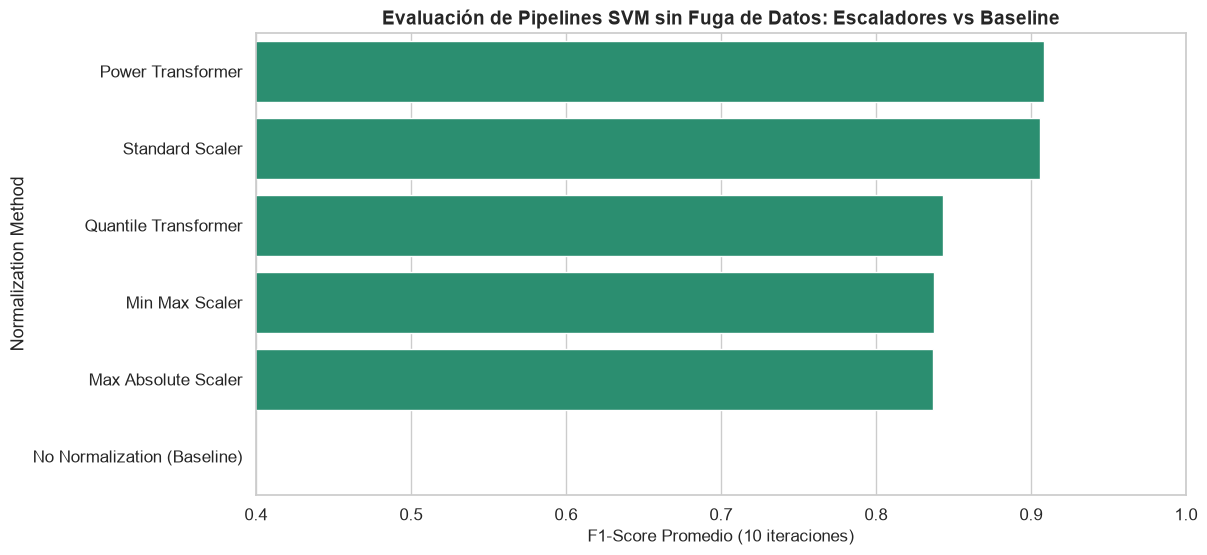

In [13]:
plt.figure(figsize=(12, 6))
colors_bar = ['#d95f02' if 'Baseline' in name else '#1b9e77' for name in summary_df['Normalization Method']]
barplot = sns.barplot(data=summary_df, x='Average F1 Score', y='Normalization Method', palette=colors_bar)
plt.title('Evaluación de Pipelines SVM sin Fuga de Datos: Escaladores vs Baseline', fontsize=14, fontweight='bold')
plt.xlabel('F1-Score Promedio (10 iteraciones)', fontsize=12)
plt.xlim(0.4, 1.0)
plt.show()

## 3. Importancia de Variables en Pipeline SVM (`n_jobs=2`)

Pipeline guardado exitosamente en 'svm_pipeline_reproducible.joblib'


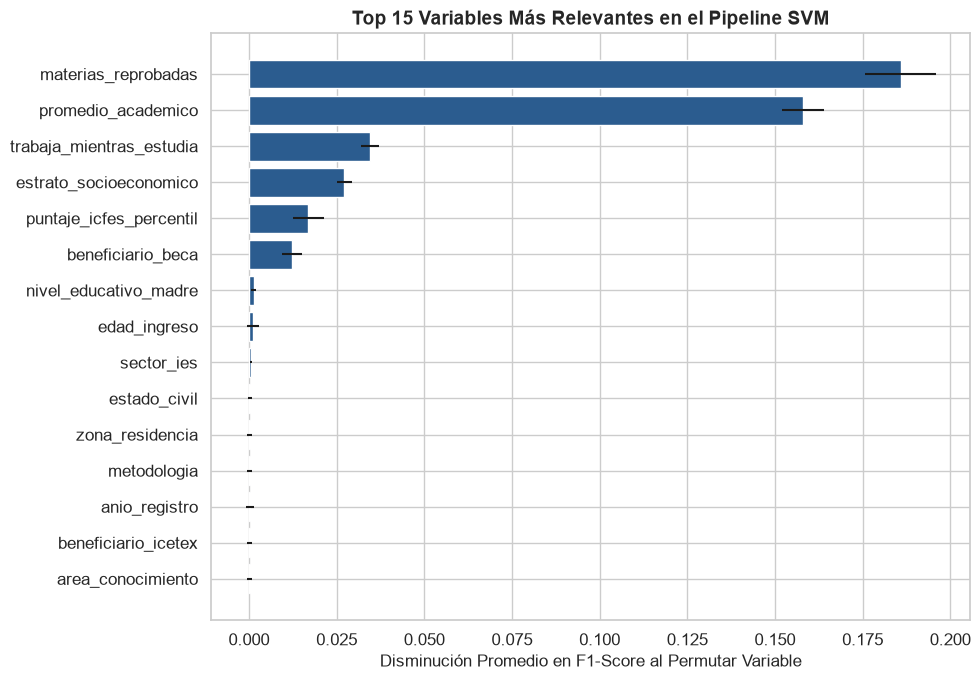

,Feature,Importance_Mean,Importance_Std
0,materias_reprobadas,0.185826,0.010046
1,promedio_academico,0.158000,0.005863
2,trabaja_mientras_estudia,0.034435,0.002571
3,estrato_socioeconomico,0.027217,0.002244
4,puntaje_icfes_percentil,0.016870,0.004463
5,beneficiario_beca,0.012174,0.002844
6,nivel_educativo_madre,0.001304,0.000674
7,edad_ingreso,0.001043,0.001752
8,sector_ies,0.000522,0.000325
9,estado_civil,0.000348,0.000507


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)

best_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

best_pipeline = Pipeline(steps=[
    ('preprocessor', best_preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, probability=True, cache_size=1000, random_state=42))
])

best_pipeline.fit(X_train, y_train)

# Guardar el Pipeline entrenado e inmutable para inferencia reproducible
dump(best_pipeline, 'svm_pipeline_reproducible.joblib')
print("Pipeline guardado exitosamente en 'svm_pipeline_reproducible.joblib'")

perm_importance = permutation_importance(
    best_pipeline, X_test, y_test, n_repeats=5, random_state=42, n_jobs=N_JOBS
)

sorted_idx = perm_importance.importances_mean.argsort()[::-1]
imp_df = pd.DataFrame({
    'Feature': X_raw.columns[sorted_idx],
    'Importance_Mean': perm_importance.importances_mean[sorted_idx],
    'Importance_Std': perm_importance.importances_std[sorted_idx]
})

plt.figure(figsize=(10, 7))
top_15_imp = imp_df.head(15)
plt.barh(top_15_imp['Feature'][::-1], top_15_imp['Importance_Mean'][::-1], color='#2b5c8f', xerr=top_15_imp['Importance_Std'][::-1])
plt.title('Top 15 Variables Más Relevantes en el Pipeline SVM', fontsize=14, fontweight='bold')
plt.xlabel('Disminución Promedio en F1-Score al Permutar Variable', fontsize=12)
plt.tight_layout()
plt.show()
display(imp_df.head(10))